# Torchvision Mask R-CNN インスタンスセグメンテーションサンプル

このNotebookでは、Torchvisionの高精度な`maskrcnn_resnet50_fpn_v2`を使用してインスタンスセグメンテーションを行います。

インスタンスセグメンテーションでは、物体を検出するだけでなく、各物体の正確なピクセルレベルのマスクを取得できます。

## 1. 必要なライブラリのインポート

In [1]:
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import torch
from PIL import Image
from matplotlib.patches import Rectangle
from torchvision.models.detection import (
    MaskRCNN_ResNet50_FPN_V2_Weights,
    maskrcnn_resnet50_fpn_v2,
)

## 2. 入力画像の読み込み

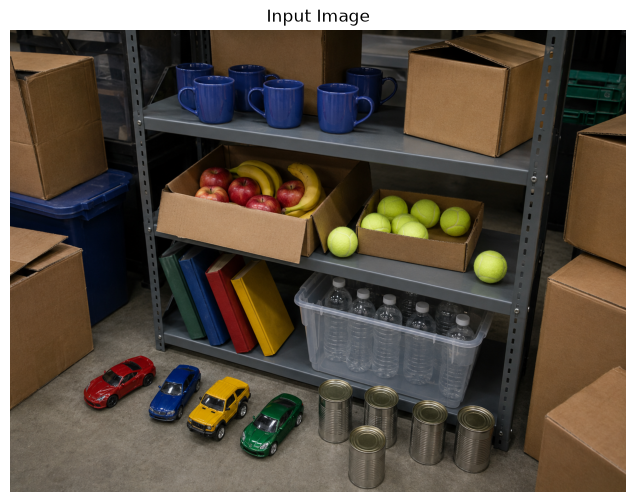

Image size: (1448, 1086)


In [2]:
image_path = '../assets/test1.png'
image = Image.open(image_path).convert('RGB')

plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.axis('off')
plt.title('Input Image')
plt.show()

print(f'Image size: {image.size}')

## 3. 高精度Mask R-CNNモデルの読み込み

COCO事前学習済みの`maskrcnn_resnet50_fpn_v2`を読み込みます。重みは初回実行時に自動ダウンロードされます。

In [3]:
weights = MaskRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = maskrcnn_resnet50_fpn_v2(weights=weights)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device).eval()

categories = weights.meta['categories']
preprocess = weights.transforms()

print(f'Model loaded on: {device}')
print(f'COCO categories: {len(categories) - 1}')

Model loaded on: cuda
COCO categories: 90


## 4. インスタンスセグメンテーションの実行

In [4]:
image_tensor = preprocess(image).to(device)

with torch.inference_mode():
    prediction = model([image_tensor])[0]

score_threshold = 0.5
keep = prediction['scores'] >= score_threshold

boxes = prediction['boxes'][keep].cpu()
labels = prediction['labels'][keep].cpu()
scores = prediction['scores'][keep].cpu()
masks = prediction['masks'][keep].cpu()

print(f'Detected {len(boxes)} objects with score >= {score_threshold}')

Detected 38 objects with score >= 0.5


## 5. セグメンテーション結果の可視化

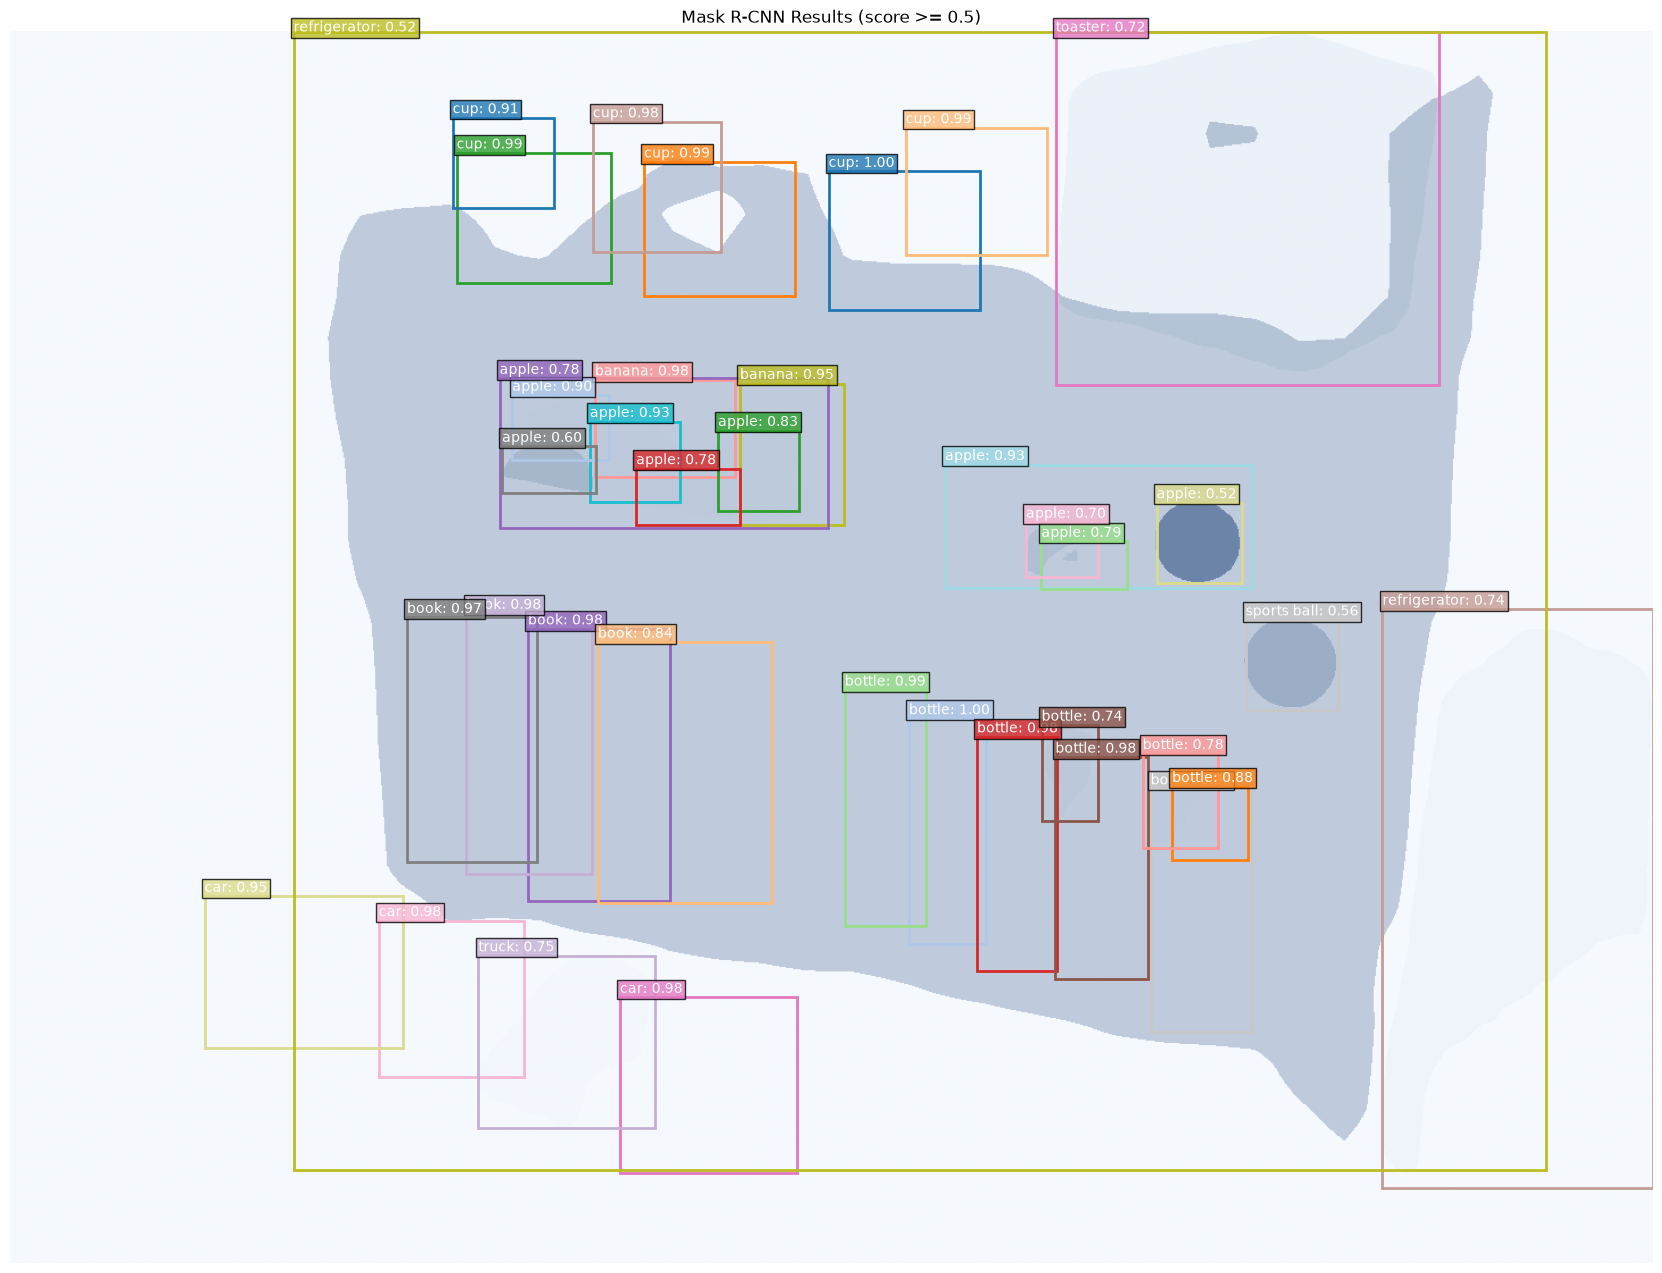

In [5]:
fig, ax = plt.subplots(figsize=(24, 16))
ax.imshow(image)
colors = plt.cm.tab20.colors

for index, (box, label, score, mask) in enumerate(zip(boxes, labels, scores, masks)):
    color = colors[index % len(colors)]
    binary_mask = mask[0] >= 0.5
    ax.imshow(binary_mask, cmap='Blues', alpha=0.35)

    x1, y1, x2, y2 = box.tolist()
    ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor=color, linewidth=2))
    class_name = categories[label.item()]
    ax.text(x1, max(y1 - 4, 0), f'{class_name}: {score:.2f}', color='white',
            bbox={'facecolor': color, 'alpha': 0.8, 'pad': 2})

ax.set_title(f'Mask R-CNN Results (score >= {score_threshold})')
ax.axis('off')
plt.show()

## 6. 検出された物体の数の集計

In [6]:
class_counts = Counter(categories[label.item()] for label in labels)
df_counts = pd.DataFrame(class_counts.items(), columns=['クラス', '検出数'])

if df_counts.empty:
    print('スコア閾値以上の物体は検出されませんでした。')
else:
    df_counts = df_counts.sort_values('検出数', ascending=False).reset_index(drop=True)
    print('### 検出された物体の数')
    print(df_counts.to_string(index=False))

print(f'\n合計: {len(boxes)} 個の物体を検出・セグメンテーション')

### 検出された物体の数
         クラス  検出数
       apple   10
      bottle    8
         cup    6
        book    4
         car    3
      banana    2
refrigerator    2
       truck    1
     toaster    1
 sports ball    1

合計: 38 個の物体を検出・セグメンテーション
